# Machine Learning Lab Notebook: Importing and Classifying Data for Training a Custom BERT model

This notebook walks students through a complete text classification workflow:

1. Load data from a CSV file  
2. Inspect and clean the dataset  
3. Define labels and features  
4. Train a simple baseline classifier  
5. Fine-tune a BERT classifier with PyTorch  
6. Evaluate the model with common metrics  

Use the included sample CSV file:

`student_tickets_sample.csv`

## Learning goals

By the end of this lab, students should be able to:

- explain the difference between features and labels
- understand many of the core machine learning, models, and evaluations
- load CSV data into a pandas DataFrame
- prepare text for machine learning
- train a baseline classifier
- fine-tune a BERT model with PyTorch
- interpret accuracy, precision, recall, and F1-score

## Important terms

### Core machine learning terms

- **Dataset**: a collection of examples used for training or evaluation
- **Data Lake**: a huge collection of raw unstructured data
- **Data Warehouse**: a huge collection of structured data
- **CSV**: comma-separated values, a simple tabular text format  
- **Feature**: an input used by the model to make a prediction  
- **Label**: the correct class or category for an example  
- **Classification**: predicting one class from a set of possible classes  
- **Supervised learning**: training with examples that already have correct labels
- **Unsupervised Learning**: using pattern recognition and predictive modelling on unlabelled data
- **Self-supervised learning**: the model uses algorithms to predict what labels should be
- **Reinforcement Learning**: the model receives positive or negative feedback on decisions
- **Semi-supervised Learning**: the model applies labels to a large unlabelled dataset based on a smaller labelled dataset
- **Hybrid Learning**: this method uses a combination of techniques
- **Descriptive Analysis**: to help understand what happened in the past.
- **Prescriptive Analysis**: to automate business decisions and processes based on data.
- **Predictive Analysis**: to predict future business scenarios.
- **Training set**: the data used to teach the model  
- **Test set**: held-out data used to measure final performance  
- **Model**: a system that learns patterns from data  
- **Epoch**: one full pass through the training data  
- **Batch**: a small group of examples processed together  
- **Loss**: a value showing how wrong the model is during training  
- **Optimizer**: the algorithm that updates model weights  
- **Class**: a pre-defined category that a value may be assigned to during classification
- **Hyperparameter**: a config variable set before learning to control the process
- **Inference**: using a trained model to make predictions
- **Parameters**: numeric tunable variables used internally as part of the learning process
- **Weights**: a tunable numeric variable used internally as part of the learning process specifically controlling the strength of the connection between neural nodes


### Model terms

- **NLP**: Natural Language Processing
- **Token**: a word or word-piece used as model input  
- **Tokenization**: splitting text into tokens  
- **Embedding**: a numeric representation of meaning  
- **Transformer**: a neural network architecture built around attention  
- **BERT**: Bidirectional Encoder Representations from Transformers
- **RoBERTa**: Robustly optimized BERT approach, using longer sequences   
- **ALBERT**: A Lite BERT, an optimized BERT model which shares parameters allowing parallelization
- **LLM**: Large lanuage models perform both encoding and decoding and are pretrained on large datasets
- **GPT**: Generative Pre-trained Transformer which is unidirectional based on previous words  
- **T5**: Text-to-Text Transfer Transformer using NLP to resolve text to test transformations
- **FLAN-T5**:  Fine-tuned Language Net T5 trained on instructions
- **XLNet**: Permutation-based bidirectional modelling
- **RNN**: Recurrent Neural Networks process data serially
- **MoE**: Mixture-of-Experts sends tokens to specific "experts" for optimization
- **Baseline model**: a simple model used to evaluate the performance of more complex algorithms
- **Pretrained model**: a model trained earlier on a large set of general text data
- **Fine-tuning**: adapting a pretrained model to a specific task  
- **Attention**: a mechanism that helps the model focus on important parts of the input  
- **CLS token**: a special marking added by BERT models to tag the sequence's meaning
- **Vocabulary**: the set of words, partial words, or characters a model is trained to understand
- **Softmax**: converts a vector of raw scores into a probability distribution


### Evaluation metrics

- **Accuracy**: percent of predictions that are correct  
- **Precision**: of the predicted positives, how many were truly positive  $\frac{TP}{TP + FP}$
- **Recall**: of the true positives, how many the model found $\frac{TP}{TP + FN}$ 
- **F1-score**: the harmonic mean between precision and recall: $F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$
- **Confusion matrix**: a table showing correct and incorrect predictions by class
- **Overfitting**: when a model memorizes training data and performs poorly on new data  
- **Underfitting**: when a model has not learned enough patterns  
- **Imbalanced Data:** when one or more classes outnumbers the other in a dataset
- **Weighted F1, Macro F1, or Balanced Metric:** balancing metrics to handle a class imbalance in the dataset
- **Validation set**: an inetermediate set seperate from traning and final test data which is used to perform evaluations
- **Support**: the number of occurances of each class in a dataset
- **TF-IDF**: Term Frequency-Inverse Document Frequency is a numerical statistic in machine learning used to measure a word's relevance within a document relative to a larger collection of documents
- **Label encoding**: assigning values to labels during preprocessing
- **Logistic Regression**: a basic binary classification algorithm based on probability
- **Logits**: raw numerical scores that represent probability of a label
- **True Positive**: when a model correctly identifies a positive value
- **False Positive**: when a model incorrectly identifies a positive value
- **True Negative**: when a model correctly identifies a negative value
- **False Negative**: when a model incorrectly identifies a negative value






In [1]:
# Install packages if needed
# Uncomment this cell if you are running in a fresh environment

# !pip install pandas scikit-learn torch transformers matplotlib

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Step 1: Load the CSV file

In [3]:
csv_path = "student_tickets_sample.csv"
df = pd.read_csv(csv_path)

print(df.head())
print()
print(df.info())
print()
print(df['label'].value_counts())

                                   text      label
0              Reset my password please    support
1            I want to buy a new laptop      sales
2              My order arrived damaged  complaint
3  Can you tell me your business hours?    general
4   I need help logging into my account    support

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    24 non-null     str  
 1   label   24 non-null     str  
dtypes: str(2)
memory usage: 516.0 bytes
None

label
support      6
sales        6
complaint    6
general      6
Name: count, dtype: int64


### Questions

- How many rows are in the dataset?
- How many unique labels are there?
- Is the class distribution balanced?
- Are there any missing values?

## Step 2: Clean and prepare the data

In [4]:
data = df[['text', 'label']].dropna().copy()
data['text'] = data['text'].astype(str).str.strip()
data['label'] = data['label'].astype(str).str.strip()

print(data.head())

                                   text      label
0              Reset my password please    support
1            I want to buy a new laptop      sales
2              My order arrived damaged  complaint
3  Can you tell me your business hours?    general
4   I need help logging into my account    support


## Step 3: Encode labels

Machine learning models work with numbers, so we convert string labels into integer IDs.

In [5]:
label_encoder = LabelEncoder()
data['label_id'] = label_encoder.fit_transform(data['label'])

label_map = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label mapping:")
print(label_map)

Label mapping:
{'complaint': 0, 'general': 1, 'sales': 2, 'support': 3}


## Step 4: Split the dataset

In [6]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    data['text'].tolist(),
    data['label_id'].tolist(),
    test_size=0.25,
    random_state=42,
    stratify=data['label_id']
)

print(f"Training samples: {len(train_texts)}")
print(f"Test samples: {len(test_texts)}")

Training samples: 18
Test samples: 6


## Step 5: Train a baseline classifier

We start with a simple and fast model: TF-IDF plus Logistic Regression.

This gives us a baseline to compare against BERT.

In [7]:
baseline_model = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])

baseline_model.fit(train_texts, train_labels)
baseline_preds = baseline_model.predict(test_texts)

print(classification_report(test_labels, baseline_preds, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

   complaint       1.00      1.00      1.00         2
     general       0.50      1.00      0.67         1
       sales       1.00      0.50      0.67         2
     support       1.00      1.00      1.00         1

    accuracy                           0.83         6
   macro avg       0.88      0.88      0.83         6
weighted avg       0.92      0.83      0.83         6



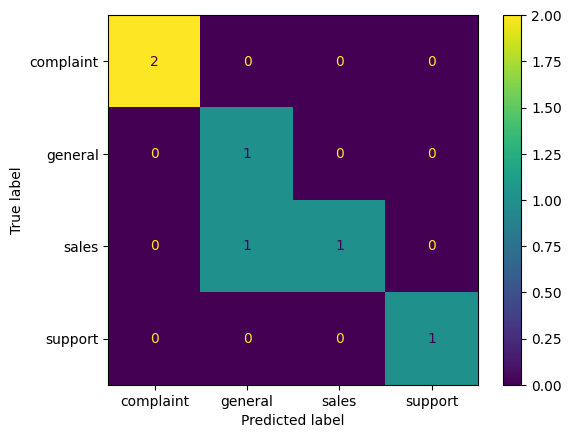

In [8]:
cm = confusion_matrix(test_labels, baseline_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.show()

## Why use a baseline first?

A baseline model is useful because:

- it is fast to train
- it helps us find data problems early
- it gives us a reference point before using a larger deep learning model

## Step 6: Import PyTorch and Transformers for BERT

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader

# Use the modern import path for AdamW
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

## Step 7: Load the tokenizer

In [10]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
tokenizer

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

## Step 8: Build a custom Dataset class

In [11]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

## Step 9: Create DataLoaders

In [12]:
train_dataset = TextDataset(train_texts, train_labels, tokenizer, max_len=64)
test_dataset = TextDataset(test_texts, test_labels, tokenizer, max_len=64)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

len(train_dataset), len(test_dataset)

(18, 6)

## Step 10: Load the BERT classifier

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(label_encoder.classes_),
    ignore_mismatched_sizes=True
)
model.to(device)

Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## Step 11: Define optimizer

In [14]:
optimizer = AdamW(model.parameters(), lr=2e-5)

## Step 12: Train the BERT model

This example uses a small number of epochs for classroom speed.

In [15]:
num_epochs = 2
training_losses = []

model.train()

for epoch in range(num_epochs):
    total_loss = 0.0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)
    training_losses.append(avg_loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {avg_loss:.4f}")

Epoch 1/2 - Loss: 1.4560
Epoch 2/2 - Loss: 1.2988


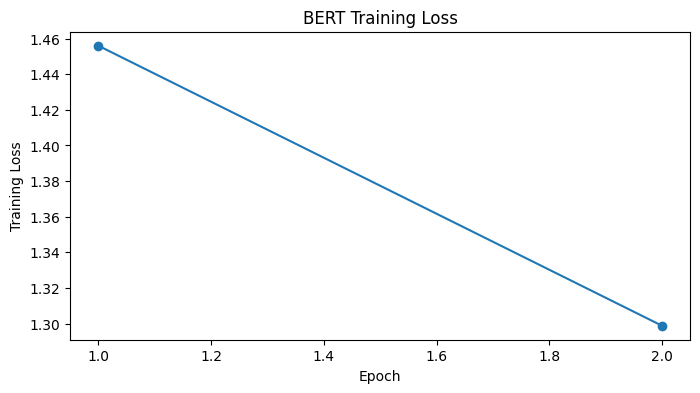

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(training_losses) + 1), training_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("BERT Training Loss")
plt.show()

## Step 13: Evaluate BERT

In [17]:
model.eval()

all_preds = []
all_true = []

# we use torch.no_grad() for a context manager setting that disables a backward pass graph for performance
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_true, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_true, all_preds, average='weighted', zero_division=0
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print()
print(classification_report(all_true, all_preds, target_names=label_encoder.classes_, zero_division=0))

Accuracy:  0.1667
Precision: 0.0333
Recall:    0.1667
F1-score:  0.0556

              precision    recall  f1-score   support

   complaint       0.00      0.00      0.00         2
     general       0.00      0.00      0.00         1
       sales       0.00      0.00      0.00         2
     support       0.20      1.00      0.33         1

    accuracy                           0.17         6
   macro avg       0.05      0.25      0.08         6
weighted avg       0.03      0.17      0.06         6



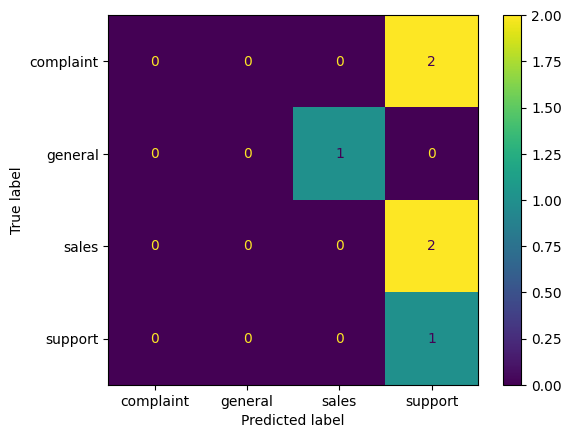

In [18]:
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.show()

## Step 14: Try inference on new text

In [19]:
sample_texts = [
    "My account password no longer works",
    "Can you send me pricing for 100 licenses?",
    "The package arrived broken and incomplete",
    "What time do you close tonight?"
]

model.eval()

for text in sample_texts:
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=64,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    # we use torch.no_grad() for a context manager setting that disables a backward pass graph for performance
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        pred_id = torch.argmax(outputs.logits, dim=1).item()

    pred_label = label_encoder.inverse_transform([pred_id])[0]
    print(f"Text: {text}")
    print(f"Predicted label: {pred_label}")
    print("-" * 60)

Text: My account password no longer works
Predicted label: support
------------------------------------------------------------
Text: Can you send me pricing for 100 licenses?
Predicted label: support
------------------------------------------------------------
Text: The package arrived broken and incomplete
Predicted label: support
------------------------------------------------------------
Text: What time do you close tonight?
Predicted label: general
------------------------------------------------------------


## Discussion and reflection

Answer these questions after running the notebook:

1. What is the role of the `label` column?  
2. Why do we split data into training and test sets?  
3. Why do we convert labels to numbers?  
4. What does the tokenizer do?  
5. Why might BERT outperform the baseline model?  
6. What does low loss suggest?  
7. What signs would suggest overfitting?  
8. Which metric matters most when false negatives are very costly?  
9. Which metric matters most when false positives are very costly?  
10. Why is it helpful to compare a simple model with a larger one?